In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg 

#### 1. Import Directory and Path Names

In [2]:
files ={
    "file1" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_01_01.jpg",
    "file2" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_01_02.jpg",
    "file3" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_02_01.png",
    "file4" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_02_02.png",
    "file5" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_03_01.jpg",
    "file6" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_03_02.jpg",
    "file7" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_04_01.jpg",
    "file8" : "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_04_02.jpg",
}


#### 2. Display Sample Images

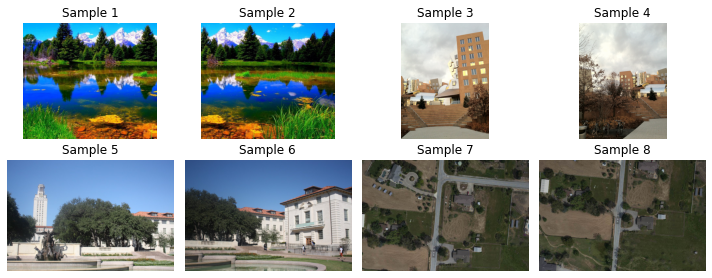

In [11]:
fig, axs = plt.subplots(2, 4,figsize=(10, 4))

for i in range(1, 5): 
    key = f"file{i}"
    img = plt.imread(f"{files[key]}")
    axs[0, i-1].set_title(f'Sample {i}')
    axs[0, i-1].imshow(img)
    for ax in axs.flatten():
        ax.axis('off')

for i in range(5, 9): 
    key = f"file{i}"
    img = plt.imread(f"{files[key]}")
    axs[1, i-5].set_title(f'Sample {i}')
    axs[1, i-5].imshow(img)
    for ax in axs.flatten():
        ax.axis('off')
plt.tight_layout()      
plt.show()

#### 3. Harris Corner Detection

In [83]:
def harris(img_dir):
    img = cv2.imread(img_dir)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)  # Turn image to gray
    gray = np.float32(gray)
    harris = cv2.cornerHarris(gray,2,3,0.04)  # blockSize=2, ksize=3, k=0.04

    
    # Normalize for visualization
    #harris_norm = np.empty(harris.shape, dtype=np.float32)
    #cv2.normalize(harris, harris_norm, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
    #harris_norm_scaled = cv2.convertScaleAbs(harris_norm)
    #corner_coords = np.argwhere(harris_norm > 0.01 * harris_norm.max())
    
    # Get coordinates of detected corners
    corner_coords = np.argwhere(harris>0.01*harris.max())
    
    # Result is dilated for marking the corners, not important
    harris = cv2.dilate(harris,None)
    
    
    # Threshold for an optimal value, it may vary depending on the image.
    img[harris>0.01*harris.max()]=[0,0,255]

    
    img_color = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    #plt.figure("Harris detector")
    #plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title("Harris")
    #plt.xticks([]), plt.yticks([])
    #plt.show()
    
    return img_color, corner_coords # 2 outputs


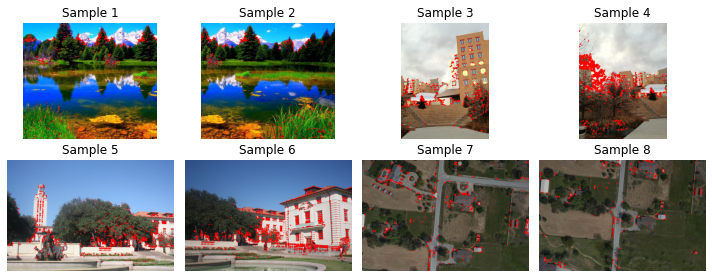

Coordinates for detected corners in Sample 1
[[  0 234]
 [  0 235]
 [  1 234]
 ...
 [709 801]
 [709 802]
 [709 803]]


Coordinates for detected corners in Sample 2
[[ 31 304]
 [ 31 305]
 [ 35 311]
 ...
 [708 634]
 [708 651]
 [708 758]]


Coordinates for detected corners in Sample 3
[[ 41 347]
 [ 61 236]
 [ 63 333]
 ...
 [497   1]
 [498   0]
 [498   1]]


Coordinates for detected corners in Sample 4
[[ 37   2]
 [ 37   3]
 [ 37   4]
 ...
 [497  35]
 [499 187]
 [499 188]]


Coordinates for detected corners in Sample 5
[[156 219]
 [157 219]
 [157 220]
 ...
 [675 747]
 [675 748]
 [675 749]]


Coordinates for detected corners in Sample 6
[[163 788]
 [164 787]
 [164 788]
 ...
 [682 859]
 [682 860]
 [682 861]]


Coordinates for detected corners in Sample 7
[[  0 125]
 [  1 125]
 [  2 286]
 ...
 [426 253]
 [426 254]
 [426 255]]


Coordinates for detected corners in Sample 8
[[  0 135]
 [  0 136]
 [  0 233]
 ...
 [426  33]
 [426 129]
 [426 130]]




In [85]:
fig, axs = plt.subplots(2, 4,figsize=(10, 4))

# For visualisation

for i in range(1, 5): 
    key = f"file{i}"
    img = f"{files[key]}" 
    outputs = harris(img)
    axs[0, i-1].set_title(f'Sample {i}')
    axs[0, i-1].imshow(outputs[0])
    for ax in axs.flatten():
        ax.axis('off')
    
for i in range(5, 9): 
    key = f"file{i}"
    img = f"{files[key]}"
    outputs = harris(img)
    axs[1, i-5].set_title(f'Sample {i}')
    axs[1, i-5].imshow(outputs[0])
    for ax in axs.flatten():
        ax.axis('off')
plt.tight_layout()      
plt.show()


# Compute corners and SIFT descriptors

for i in range(1, 9): 
    key = f"file{i}"
    img = f"{files[key]}"
    outputs = harris(img)
    #descriptors = sift_descriptor(img, outputs[1])
    print(f"Coordinates for detected corners in Sample {i}")
    print(outputs[1])
    print("\n")
    
    #print(f"SIFT Descriptors for Sample {i}")
    #print(descriptors)
    #print("\n")

range(0, 8820)


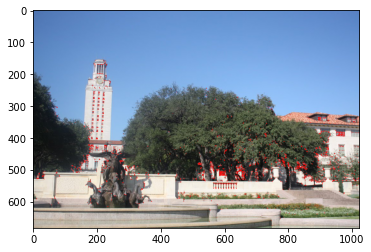

(683, 1024, 3)


In [87]:
img = cv2.imread("/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_03_01.jpg")
outputs = harris("/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_03_01.jpg")
#print(outputs[1][580778][0])
print(range(len(outputs[1])))
for n in range(len(outputs[1])):
    img[outputs[1][n][0]][outputs[1][n][1]]=[0, 0, 255]

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()
print(img.shape)

#### 4. SIFT Descriptor

In [137]:
def sift(imgdir,corner_loc):
    sift = cv2.xfeatures2d.SIFT_create()
    keypoints=[]
    for n in range(len(corner_loc)):
        kp = cv2.KeyPoint(float(corner_loc[n][1]),float(corner_loc[n][0]),10)
        keypoints.append(kp)
    img=cv2.imread(imgdir,0)
    keypoints, descriptors = sift.compute(img,keypoints)
    return keypoints, descriptors


def homography(descriptor1,keypoints1,descriptor2,keypoints2):
    matcher = cv2.BFMatcher()
    raw_matches = matcher.knnMatch(descriptor1, descriptor2, k=2)
    good_points = []
    good_matches=[]
    for m1, m2 in raw_matches:
        if m1.distance < 0.85 * m2.distance:
            good_points.append((m1.trainIdx, m1.queryIdx))
            good_matches.append([m1])

    if len(good_points) > 8:
        image1_kp = np.float32(
            [keypoints1[i].pt for (_, i) in good_points])
        image2_kp = np.float32(
            [keypoints2[i].pt for (i, _) in good_points])
    
    (H, status) = cv2.findHomography(image2_kp, image1_kp, cv2.RANSAC, 5)
    
    return H

def mask(img1,img2,version):
    smoothing_window_size=188
    height_img1 = img1.shape[0]
    width_img1 = img1.shape[1]
    width_img2 = img2.shape[1]
    height_panorama = height_img1
    width_panorama = width_img1 +width_img2
    offset = int(smoothing_window_size / 2)
    barrier = img1.shape[1] - int(smoothing_window_size / 2)
    mask = np.zeros((height_panorama, width_panorama))
    if version== 'left_image':
        mask[:, barrier - offset:barrier + offset ] = np.tile(np.linspace(1, 0, 2 * offset ).T, (height_panorama, 1))
        mask[:, :barrier - offset] = 1
    else:
        mask[:, barrier - offset :barrier + offset ] = np.tile(np.linspace(0, 1, 2 * offset ).T, (height_panorama, 1))
        mask[:, barrier + offset:] = 1
    return cv2.merge([mask, mask, mask])

def blending(img1,img2,H):
    height_img1 = img1.shape[0]
    width_img1 = img1.shape[1]
    width_img2 = img2.shape[1]
    height_panorama = height_img1
    width_panorama = width_img1 +width_img2

    panorama1 = np.zeros((height_panorama, width_panorama, 3))
    mask1 = mask(img1,img2,version='left_image')
    panorama1[0:img1.shape[0], 0:img1.shape[1], :] = img1
    panorama1 *= mask1
    mask2 = mask(img1,img2,version='right_image')
    panorama2 = cv2.warpPerspective(img2, H, (width_panorama, height_panorama))*mask2
    result=panorama1+panorama2

    rows, cols = np.where(result[:, :, 0] != 0)
    min_row, max_row = min(rows), max(rows) + 1
    min_col, max_col = min(cols), max(cols) + 1
    final_result = result[min_row:max_row, min_col:max_col, :]
    return final_result

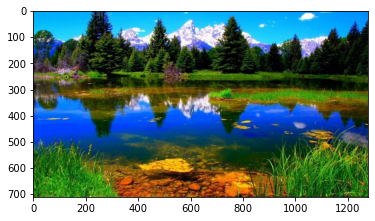

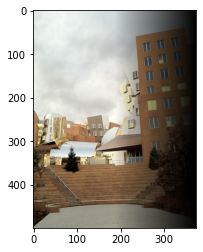

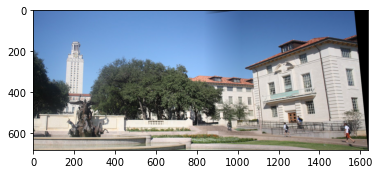

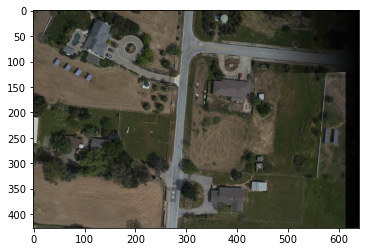

In [138]:
def image_stitch(imgdir1,imgdir2):
    #Intialize variables
    keypoints={}  
    descriptors={}  

    corner_loc1=harris(imgdir1)
    corner_loc2=harris(imgdir2)

    keypoints1, descriptors1=run_sift(imgdir1,corner_loc1[1])
    keypoints2, descriptors2=run_sift(imgdir2,corner_loc2[1])
    
    #Get homography matrix
    H=homography(descriptors1,keypoints1,descriptors2,keypoints2)
    
    #Load images
    img1 = cv2.imread(imgdir1)
    img2 = cv2.imread(imgdir2)
    
    #Create composite image
    result=blending(img1,img2,H)
    result=result.astype(np.uint8)
    result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    
    return result
    
result1 = image_stitch("/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_01_01.jpg",
                     "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_01_02.jpg")
result2 = image_stitch("/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_02_01.png",
                     "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_02_02.png")
result3 = image_stitch("/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_03_01.jpg",
                     "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_03_02.jpg")
result4 = image_stitch("/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_04_01.jpg",
                     "/Users/azd/Desktop/CV - Assignment 2/image pairs/image pairs_04_02.jpg")

plt.imshow(result1)
plt.show()
plt.imshow(result2)
plt.show()
plt.imshow(result3)
plt.show()
plt.imshow(result4)
plt.show()